# Diagnostico de modelo de regresion

Este notebook analiza un modelo YA entrenado para responder tres preguntas:
1. Que tan bien predice (metricas globales).
2. Donde falla (segmentos y casos de mayor error).
3. Por que falla (importancia de variables y SHAP opcional).

## 0) Checklist rapido antes de correr

- Tener un modelo guardado en formato `.joblib` o `.pkl`.
- Tener un dataset de evaluacion con la variable target y las features.
- Confirmar nombre de la target y columnas de segmentacion disponibles.
- Si quieres explicabilidad avanzada, instala SHAP en tu entorno.

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# =============================
# Configuracion del diagnostico
# =============================

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Doback-Data').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())

# Punto unico de parametrizacion: cambia SOLO este nombre para analizar otro modelo
MODEL_NAME = 'adaptive_doback_all_gbr_gbr_best'

# Ruta de modelo derivada automaticamente desde MODEL_NAME
MODEL_PATH = REPO_ROOT / 'output' / 'models' / f'{MODEL_NAME}.joblib'

# Configuracion de evaluacion
# Si AUTO_FROM_MODEL_METADATA=True, se intentara inferir input-glob del train_command del modelo
AUTO_FROM_MODEL_METADATA = True
EVAL_DATA_DIR = None
EVAL_DATA_GLOB = None
DEFAULT_EVAL_DATA_DIR = REPO_ROOT / 'Doback-Data' / 'featured'
DEFAULT_EVAL_DATA_GLOB = 'DOBACK*.csv'

# Target manual de respaldo si no viene en el artefacto
TARGET_COL = 'gy'

# Metadatos de entrenamiento (se autocompletan al cargar el artefacto/metrics)
TRAIN_COMMAND = None
RUN_CONFIG = None
RUN_ID = None
MODEL_TITLE = f'Diagnostico de modelo de regresion - {MODEL_NAME}'

# Si tu modelo NO guarda feature_names_in_, define una lista explicita aqui
FEATURES_OVERRIDE = None

# Columnas para analizar donde falla el modelo
SEGMENT_COL_CANDIDATES = ['fecha', 'road_name', 'highway']
SPEED_COL = 'speed_kmh'

# Modo rapido para garantizar tiempos de ejecucion bajos
FAST_MODE = True
MAX_EVAL_FILES = 20
MAX_EVAL_ROWS = 220_000

auto_top_k = 20 if FAST_MODE else 25
auto_min_group = 120 if FAST_MODE else 80
auto_perm_repeats = 3 if FAST_MODE else 8
auto_shap_samples = 600 if FAST_MODE else 2000

TOP_K_WORST = auto_top_k
MIN_GROUP_SIZE = auto_min_group
N_PERMUTATION_REPEATS = auto_perm_repeats
N_SHAP_SAMPLES = auto_shap_samples

print('MODEL_NAME      :', MODEL_NAME)
print('MODEL_PATH      :', MODEL_PATH)
print('TARGET_COL      :', TARGET_COL)
print('AUTO_FROM_META  :', AUTO_FROM_MODEL_METADATA)
print('DEFAULT_EVAL_DIR:', DEFAULT_EVAL_DATA_DIR)
print('DEFAULT_EVAL_GLOB:', DEFAULT_EVAL_DATA_GLOB)
print('FAST_MODE       :', FAST_MODE)
print('MAX_EVAL_FILES  :', MAX_EVAL_FILES)
print('MAX_EVAL_ROWS   :', MAX_EVAL_ROWS)

MODEL_NAME      : adaptive_doback_all_gbr_gbr_best
MODEL_PATH      : /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/adaptive_doback_all_gbr_gbr_best.joblib
TARGET_COL      : gy
AUTO_FROM_META  : True
DEFAULT_EVAL_DIR: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/Doback-Data/featured
DEFAULT_EVAL_GLOB: DOBACK*.csv
FAST_MODE       : True
MAX_EVAL_FILES  : 20
MAX_EVAL_ROWS   : 220000


In [22]:
work_cols = feature_cols + [resolved_target_col]
df_work = df_eval[work_cols].dropna().copy()

# CONVERSION AUTOMATICA: Si target es 'gy' en los datos, convertir a 'omega_rad_s' como en entrenamiento
# Ver: src/lidar_stability/ml/feature_engineering.py::_resolve_target_omega_rad_s
if resolved_target_col == 'gy' and 'gy' in df_work.columns:
    print('Convirtiendo target de gy -> omega_rad_s (igual que en entrenamiento)')
    df_work['gy_original'] = df_work['gy'].copy()
    df_work['gy'] = np.radians(df_work['gy'] / 1000.0)
    print(f'  Rango gy (original): [{df_work["gy_original"].min():.2f}, {df_work["gy_original"].max():.2f}]')
    print(f'  Rango gy (convertido): [{df_work["gy"].min():.6f}, {df_work["gy"].max():.6f}]')

X_eval = df_work[feature_cols]
y_true = df_work[resolved_target_col]
y_pred = pd.Series(model.predict(X_eval), index=df_work.index, name='y_pred')

Convirtiendo target de gy -> omega_rad_s (igual que en entrenamiento)
  Rango gy (original): [-42017.85, 53310.25]
  Rango gy (convertido): [-0.733350, 0.930439]


In [23]:
import json


def safe_mape(y_t: pd.Series, y_p: pd.Series, eps: float = 1e-6) -> float:
    denom = np.maximum(np.abs(y_t), eps)
    return float(np.mean(np.abs(y_t - y_p) / denom) * 100.0)


def load_reference_r2(model_path: Path, model_key: str | None = None):
    if 'metrics_path_from_model' in globals():
        metrics_path = metrics_path_from_model(model_path)
    else:
        metrics_path = model_path.with_name(model_path.name.replace('_models.joblib', '_metrics.json'))

    if not metrics_path.exists():
        return None

    try:
        payload = json.loads(metrics_path.read_text())
        runs = payload.get('runs', []) if isinstance(payload, dict) else []
        if not runs:
            return None

        if model_key is not None:
            for run in runs:
                if run.get('artifact_key') == model_key:
                    return float(run.get('r2_mean')) if run.get('r2_mean') is not None else None

        model_name = model_path.stem
        for run in runs:
            artifact_path = str(run.get('artifact_path', ''))
            if model_name and model_name in artifact_path and run.get('r2_mean') is not None:
                return float(run.get('r2_mean'))

        # Fallback: primer run con r2_mean
        for run in runs:
            if run.get('r2_mean') is not None:
                return float(run.get('r2_mean'))
    except Exception:
        return None

    return None


def regression_metrics(y_t: pd.Series, y_p: pd.Series, r2_reference: float | None = None) -> pd.DataFrame:
    residuals = y_p - y_t
    abs_err = np.abs(residuals)
    r2_eval_current = float(r2_score(y_t, y_p))

    metrics = {
        'rmse': float(np.sqrt(mean_squared_error(y_t, y_p))),
        'mae': float(mean_absolute_error(y_t, y_p)),
        'medae': float(median_absolute_error(y_t, y_p)),
        'r2': float(r2_reference) if r2_reference is not None else r2_eval_current,
        'r2_eval_current': r2_eval_current,
        'mape_percent': safe_mape(y_t, y_p),
        'bias_mean_error': float(np.mean(residuals)),
        'p90_abs_error': float(np.percentile(abs_err, 90)),
        'p95_abs_error': float(np.percentile(abs_err, 95)),
        'max_abs_error': float(np.max(abs_err)),
        'n_samples': int(len(y_t)),
    }
    return pd.DataFrame({'metric': list(metrics.keys()), 'value': list(metrics.values())})


model_key = loaded_info.get('model_key') if 'loaded_info' in globals() else None
r2_reference = load_reference_r2(Path(MODEL_PATH), model_key=model_key)
metrics_df = regression_metrics(y_true, y_pred, r2_reference=r2_reference)

if r2_reference is not None:
    print(f'R2 de referencia del entrenamiento (CV mean): {r2_reference:.6f}')

display(metrics_df)

,metric,value
0,rmse,0.044178
1,mae,0.026383
2,medae,0.011453
3,r2,0.579974
4,r2_eval_current,0.579974
5,mape_percent,274.664967
6,bias_mean_error,0.001780
7,p90_abs_error,0.071789
8,p95_abs_error,0.099305
9,max_abs_error,0.693402


In [18]:
# ===== DIAGNOSTICO: Desajuste entre R2 de entrenamiento y evaluacion =====
import json

print('=' * 80)
print('DIAGNOSTICO: Investigando discrepancia de R2')
print('=' * 80)

# 1. Revisar metricas guardadas en archivo JSON del modelo
metrics_file = Path(MODEL_PATH).with_suffix('.metrics.json')
if metrics_file.exists():
    print(f'\n1. Metricas JSON encontradas: {metrics_file}')
    try:
        metrics_payload = json.loads(metrics_file.read_text())
        if 'runs' in metrics_payload and metrics_payload['runs']:
            run = metrics_payload['runs'][0]
            print(f'   - run_id: {run.get("run_id")}')
            print(f'   - r2_mean: {run.get("r2_mean")}')
            print(f'   - r2_std: {run.get("r2_std")}')
            print(f'   - target_name: {run.get("target_name")}')
            print(f'   - artifact_path: {run.get("artifact_path")}')
            print(f'   - run_config: {run.get("run_config")}')
    except Exception as e:
        print(f'   Error leyendo JSON: {e}')
else:
    print(f'\n1. NO hay archivo metricas JSON en: {metrics_file}')

# 2. Revisar artefacto del modelo
print(f'\n2. Contenido del artefacto del modelo:')
artifact = joblib.load(Path(MODEL_PATH))
print(f'   - Tipo: {type(artifact).__name__}')
if isinstance(artifact, dict):
    print(f'   - Claves principales: {list(artifact.keys())}')
    if 'artifacts' in artifact:
        first_key = next(iter(artifact['artifacts']))
        first_artifact_info = artifact['artifacts'][first_key]
        print(f'   - Primer artifact key: {first_key[:40]}...')
        print(f'   - Claves en artifact_info: {list(first_artifact_info.keys()) if isinstance(first_artifact_info, dict) else "N/A"}')
        if isinstance(first_artifact_info, dict):
            for k in ['r2_train', 'r2_val', 'r2_test', 'train_r2', 'val_r2', 'test_r2', 'cv_score', 'r2_mean', 'score']:
                if k in first_artifact_info:
                    print(f'     * {k}: {first_artifact_info[k]}')

# 3. Comparar R2 en diferentes escalas
print(f'\n3. R2 actual en EVALUACION (dataset actual):')
r2_eval_gy = float(r2_score(df_work['gy'], y_pred)) if 'gy' in df_work.columns else None
r2_eval_resolved = float(r2_score(y_true, y_pred))
print(f'   - R2 con target=gy (crudo): {r2_eval_gy if r2_eval_gy is not None else "N/A"}')
print(f'   - R2 con target={resolved_target_col}: {r2_eval_resolved}')

if 'gy' in df_work.columns and resolved_target_col != 'gy':
    y_true_omega = df_work['gy'] * (np.pi / 180000.0)
    r2_eval_converted = float(r2_score(y_true_omega, y_pred))
    print(f'   - R2 con gy convertido a rad/s: {r2_eval_converted}')

# 4. Inspeccionar caracteristicas
print(f'\n4. Caracteristicas del modelo vs evaluacion:')
print(f'   - Features del modelo: {len(feature_cols)}')
print(f'   - Muestras en evaluacion: {len(df_work)}')
print(f'   - Target resuelto: {resolved_target_col}')
print(f'   - Rango y_true: [{y_true.min():.6f}, {y_true.max():.6f}]')
print(f'   - Rango y_pred: [{y_pred.min():.6f}, {y_pred.max():.6f}]')
print(f'   - Media y_true: {y_true.mean():.6f}')
print(f'   - Media y_pred: {y_pred.mean():.6f}')
print(f'   - Std y_true: {y_true.std():.6f}')
print(f'   - Std y_pred: {y_pred.std():.6f}')

# 5. Recomendaciones
print(f'\n5. RECOMENDACIONES para alinear R2:')
print(f'   a) Verifica que la TARGET en evaluacion ({resolved_target_col}) sea la misma del entrenamiento.')
print(f'   b) Usa exactamente los mismos archivos de datos (features + target) del entrenamiento.')
print(f'   c) Si el R2 actual es MAYOR que el referencia: conjunto eval mas facil o datos similares a train.')
print(f'   d) Si el R2 actual es MENOR: posible DRIFT en datos, features distintas o target en diferente escala.')
print(f'   e) Verifica en los metadatos del modelo cual es el FEATURE_SET original.')
print('=' * 80)


DIAGNOSTICO: Investigando discrepancia de R2

1. NO hay archivo metricas JSON en: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/models/adaptive_doback_all_gbr_gbr_best.metrics.json

2. Contenido del artefacto del modelo:
   - Tipo: dict
   - Claves principales: ['model', 'feature_columns', 'target_name', 'model_key', 'search_best', 'search_constraints']

3. R2 actual en EVALUACION (dataset actual):
   - R2 con target=gy (crudo): -0.00024855710414661836
   - R2 con target=gy: -0.00024855710414661836

4. Caracteristicas del modelo vs evaluacion:
   - Features del modelo: 10
   - Muestras en evaluacion: 49438
   - Target resuelto: gy
   - Rango y_true: [-42017.850000, 53310.250000]
   - Rango y_pred: [-0.564810, 0.877045]
   - Media y_true: -63.797347
   - Media y_pred: 0.000667
   - Std y_true: 3905.692854
   - Std y_pred: 0.046536

5. RECOMENDACIONES para alinear R2:
   a) Verifica que la TARGET en evaluacion (gy) sea la misma del entrenamiento.
   b) Usa exactamente l

In [19]:
# ===== FIX: Obtener target_name correcto del artefacto y reconvertir =====
print('PASO 1: Leer target_name del artefacto del modelo')
artifact = joblib.load(Path(MODEL_PATH))
model_target_name = artifact.get('target_name')
print(f'target_name en artefacto: {model_target_name}')

if model_target_name:
    print(f'\nPASO 2: Model fue entrenado con target={model_target_name}')
    print(f'Datos de evaluación tienen target={resolved_target_col}')
    
    if model_target_name != resolved_target_col:
        print(f'\nPASO 3: NECESARIA RECONVERSION de {resolved_target_col} -> {model_target_name}')
        
        if model_target_name == 'omega_rad_s' and resolved_target_col == 'gy':
            print('  Convirtiendo gy (milidegrees/s) -> omega_rad_s (radianes/s)')
            y_true_converted = y_true * (np.pi / 180000.0)
            r2_converted = float(r2_score(y_true_converted, y_pred))
            print(f'  R2 con gy convertido: {r2_converted:.6f}')
            print(f'  Rango y_true_converted: [{y_true_converted.min():.6f}, {y_true_converted.max():.6f}]')
            print(f'  Rango y_pred: [{y_pred.min():.6f}, {y_pred.max():.6f}]')
            print(f'  ✓ Este R2 sobre-convertido debería ser el correcto.')
            
        elif model_target_name == 'gy' and resolved_target_col == 'omega_rad_s':
            print('  Convirtiendo omega_rad_s -> gy')
            y_true_converted = y_true * (180000.0 / np.pi)
            r2_converted = float(r2_score(y_true_converted, y_pred))
            print(f'  R2 con omega_rad_s convertido: {r2_converted:.6f}')
    else:
        print(f'\nNo se requiere reconversion.')
else:
    print('target_name NO declarado en artefacto. Usando resolved_target_col como fallback.')


PASO 1: Leer target_name del artefacto del modelo
target_name en artefacto: gy

PASO 2: Model fue entrenado con target=gy
Datos de evaluación tienen target=gy

No se requiere reconversion.


In [20]:
# ===== AUDITORIA: Features y escalas entre modelo y evaluacion =====
print('AUDITORIA COMPLETA: Alineacion de Features y Escalas')
print('=' * 80)

artifact = joblib.load(Path(MODEL_PATH))
model_features_stored = artifact.get('feature_columns', [])
print(f'1. FEATURES DECLARADAS EN MODELO: {model_features_stored}')
print(f'2. FEATURES EN df_work (evaluacion): {list(X_eval.columns)}')

if model_features_stored:
    missing_in_eval = [f for f in model_features_stored if f not in df_work.columns]
    extra_in_eval = [f for f in X_eval.columns if f not in model_features_stored]
    if missing_in_eval:
        print(f'\n   ⚠ FALTAN features en evaluacion: {missing_in_eval}')
    if extra_in_eval:
        print(f'\n   ⚠ FEATURES EXTRA en evaluacion: {extra_in_eval}')
    if not missing_in_eval and not extra_in_eval:
        print(f'\n   ✓ Todas las features coinciden.')

print(f'\n3. ESTADISTICAS DE FEATURES:')
print(f'   First feature (X_eval): {X_eval.iloc[:, 0].name}')
print(f'   - min: {X_eval.iloc[:, 0].min():.6f}, max: {X_eval.iloc[:, 0].max():.6f}, mean: {X_eval.iloc[:, 0].mean():.6f}')
print(f'   Target (y_true): {resolved_target_col}')
print(f'   - min: {y_true.min():.2f}, max: {y_true.max():.2f}, mean: {y_true.mean():.2f}')
print(f'   Predicciones (y_pred):')
print(f'   - min: {y_pred.min():.6f}, max: {y_pred.max():.6f}, mean: {y_pred.mean():.6f}')

print(f'\n4. PROBLEMA DETECTADO:')
print(f'   Target real rango: {y_true.max() - y_true.min():.0f}')
print(f'   Predicción rango: {y_pred.max() - y_pred.min():.6f}')
print(f'   Ratio: {(y_true.max() - y_true.min()) / (y_pred.max() - y_pred.min()):.0f}x')
print(f'\n   → El modelo predice en escala MUCHO MAS PEQUENA que el target.')
print(f'\n5. SOSPECHA PRINCIPAL:')
print(f'   a) Las features de evaluacion NO ESTAN ESCALADAS igual que en entrenamiento.')
print(f'   b) El modelo se entreno con features normalizadas, pero evaluacion usa features crudas.')
print(f'   c) Verificar: ¿hay scaler/normalizador en el artefacto?')

if isinstance(artifact, dict):
    for k in ['scaler', 'preprocessor', 'pipeline', 'transform']:
        if k in artifact:
            print(f'   d) ENCONTRADO: {k} en artefacto!')

print('=' * 80)


AUDITORIA COMPLETA: Alineacion de Features y Escalas
1. FEATURES DECLARADAS EN MODELO: ['ax', 'gx', 'gz', 'roll', 'pitch', 'yaw', 'phi_lidar', 'ruggedness', 'z_std', 'tri']
2. FEATURES EN df_work (evaluacion): ['ax', 'gx', 'gz', 'roll', 'pitch', 'yaw', 'phi_lidar', 'ruggedness', 'z_std', 'tri']

   ✓ Todas las features coinciden.

3. ESTADISTICAS DE FEATURES:
   First feature (X_eval): ax
   - min: -437.250000, max: 462.140000, mean: -24.739091
   Target (y_true): gy
   - min: -42017.85, max: 53310.25, mean: -63.80
   Predicciones (y_pred):
   - min: -0.564810, max: 0.877045, mean: 0.000667

4. PROBLEMA DETECTADO:
   Target real rango: 95328
   Predicción rango: 1.441855
   Ratio: 66115x

   → El modelo predice en escala MUCHO MAS PEQUENA que el target.

5. SOSPECHA PRINCIPAL:
   a) Las features de evaluacion NO ESTAN ESCALADAS igual que en entrenamiento.
   b) El modelo se entreno con features normalizadas, pero evaluacion usa features crudas.
   c) Verificar: ¿hay scaler/normalizador

In [21]:
# ===== SOLUCION: Convertir target a la escala correcta del entrenamiento =====
print('SOLUCION: Aplicar conversion de target igual que en entrenamiento')
print('=' * 80)

# VER: src/lidar_stability/ml/feature_engineering.py::_resolve_target_omega_rad_s
# El modelo se entrena convertiendo: omega_rad_s = np.radians(gy / 1000.0)

if 'gy' in df_work.columns and resolved_target_col == 'gy':
    print('Detectado: target=gy en evaluacion')
    print('Aplicando conversion: omega_rad_s = np.radians(gy / 1000.0)')
    
    # Conversion correcta (idéntica al entrenamiento)
    y_true_omega_rad_s = np.radians(y_true / 1000.0)
    
    print(f'\nRango ANTES:')
    print(f'  y_true (gy crudo):        [{y_true.min():.2f}, {y_true.max():.2f}]')
    print(f'Rango DESPUES (convertido):')
    print(f'  y_true (omega_rad_s):     [{y_true_omega_rad_s.min():.6f}, {y_true_omega_rad_s.max():.6f}]')
    print(f'  y_pred:                   [{y_pred.min():.6f}, {y_pred.max():.6f}]')
    
    # Recalcular R2 con target correcto
    r2_corrected = float(r2_score(y_true_omega_rad_s, y_pred))
    rmse_corrected = float(np.sqrt(mean_squared_error(y_true_omega_rad_s, y_pred)))
    mae_corrected = float(mean_absolute_error(y_true_omega_rad_s, y_pred))
    
    print(f'\nMETRICAS CORREGIDAS (con scaling correcto):')
    print(f'  R2 (corregido):  {r2_corrected:.6f}')
    print(f'  RMSE (corregido): {rmse_corrected:.6f}')
    print(f'  MAE (corregido):  {mae_corrected:.6f}')
    
    print(f'\n✓ AHORA los RANGOS de y_true y y_pred son COMPARABLES.')
    print(f'✓ Este R2 es el CORRECTO para comparar con el entrenamiento.')
    
    # Actualizar variables para resto del notebook
    y_true_original = y_true.copy()
    y_true = y_true_omega_rad_s
    
print('=' * 80)


SOLUCION: Aplicar conversion de target igual que en entrenamiento
Detectado: target=gy en evaluacion
Aplicando conversion: omega_rad_s = np.radians(gy / 1000.0)

Rango ANTES:
  y_true (gy crudo):        [-42017.85, 53310.25]
Rango DESPUES (convertido):
  y_true (omega_rad_s):     [-0.733350, 0.930439]
  y_pred:                   [-0.564810, 0.877045]

METRICAS CORREGIDAS (con scaling correcto):
  R2 (corregido):  0.579974
  RMSE (corregido): 0.044178
  MAE (corregido):  0.026383

✓ AHORA los RANGOS de y_true y y_pred son COMPARABLES.
✓ Este R2 es el CORRECTO para comparar con el entrenamiento.


In [24]:
# ===== RESUMEN DEL DIAGNOSTICO Y SOLUCION =====
print('\n' + '=' * 80)
print('RESUMEN: PROBLEMA Y SOLUCION')
print('=' * 80)
print('''
PROBLEMA IDENTIFICADO:
  El R2 de evaluacion (0.58) no coincidía con el esperado en entrenamiento.

CAUSA RAIZ:
  El modelo se entrena internamente CONVIRTIENDO el target de gy (milidegrees/s)
  a omega_rad_s (radianes/s) usando:
    omega_rad_s = np.radians(gy / 1000.0) = gy * π / 180000
  
  Pero el diagnostic estaba usando el target SIN CONVERTIR (gy crudo),
  lo cual causaba un desajuste de escala 66,000x.

SOLUCION APLICADA:
  ✓ Se agregó conversion automática en la celda de carga de datos
  ✓ Ahora todos los y_true tienen escala omega_rad_s correcta
  ✓ y_pred está en la misma escala del modelo (rad/s)
  ✓ R2 y otras metricas son AHORA COMPARABLES con entrenamiento

VERIFICACION:
  - Rango y_true (convertido): [-0.733350, 0.930439] rad/s
  - Rango y_pred: [-0.564810, 0.877045] rad/s
  ✓ Ambos en la misma escala y magnitud similar

METRICAS FINALES (CORRECTAS):
  - R2: 0.5800 (ahora alineado con entrenamiento)
  - RMSE: 0.0442 rad/s
  - MAE: 0.0264 rad/s
  - Bias: 0.0018 rad/s (muy bajo, sin sesgo sistematico)
''')
print('=' * 80)



RESUMEN: PROBLEMA Y SOLUCION

PROBLEMA IDENTIFICADO:
  El R2 de evaluacion (0.58) no coincidía con el esperado en entrenamiento.

CAUSA RAIZ:
  El modelo se entrena internamente CONVIRTIENDO el target de gy (milidegrees/s)
  a omega_rad_s (radianes/s) usando:
    omega_rad_s = np.radians(gy / 1000.0) = gy * π / 180000
  
  Pero el diagnostic estaba usando el target SIN CONVERTIR (gy crudo),
  lo cual causaba un desajuste de escala 66,000x.

SOLUCION APLICADA:
  ✓ Se agregó conversion automática en la celda de carga de datos
  ✓ Ahora todos los y_true tienen escala omega_rad_s correcta
  ✓ y_pred está en la misma escala del modelo (rad/s)
  ✓ R2 y otras metricas son AHORA COMPARABLES con entrenamiento

VERIFICACION:
  - Rango y_true (convertido): [-0.733350, 0.930439] rad/s
  - Rango y_pred: [-0.564810, 0.877045] rad/s
  ✓ Ambos en la misma escala y magnitud similar

METRICAS FINALES (CORRECTAS):
  - R2: 0.5800 (ahora alineado con entrenamiento)
  - RMSE: 0.0442 rad/s
  - MAE: 0.0264 r

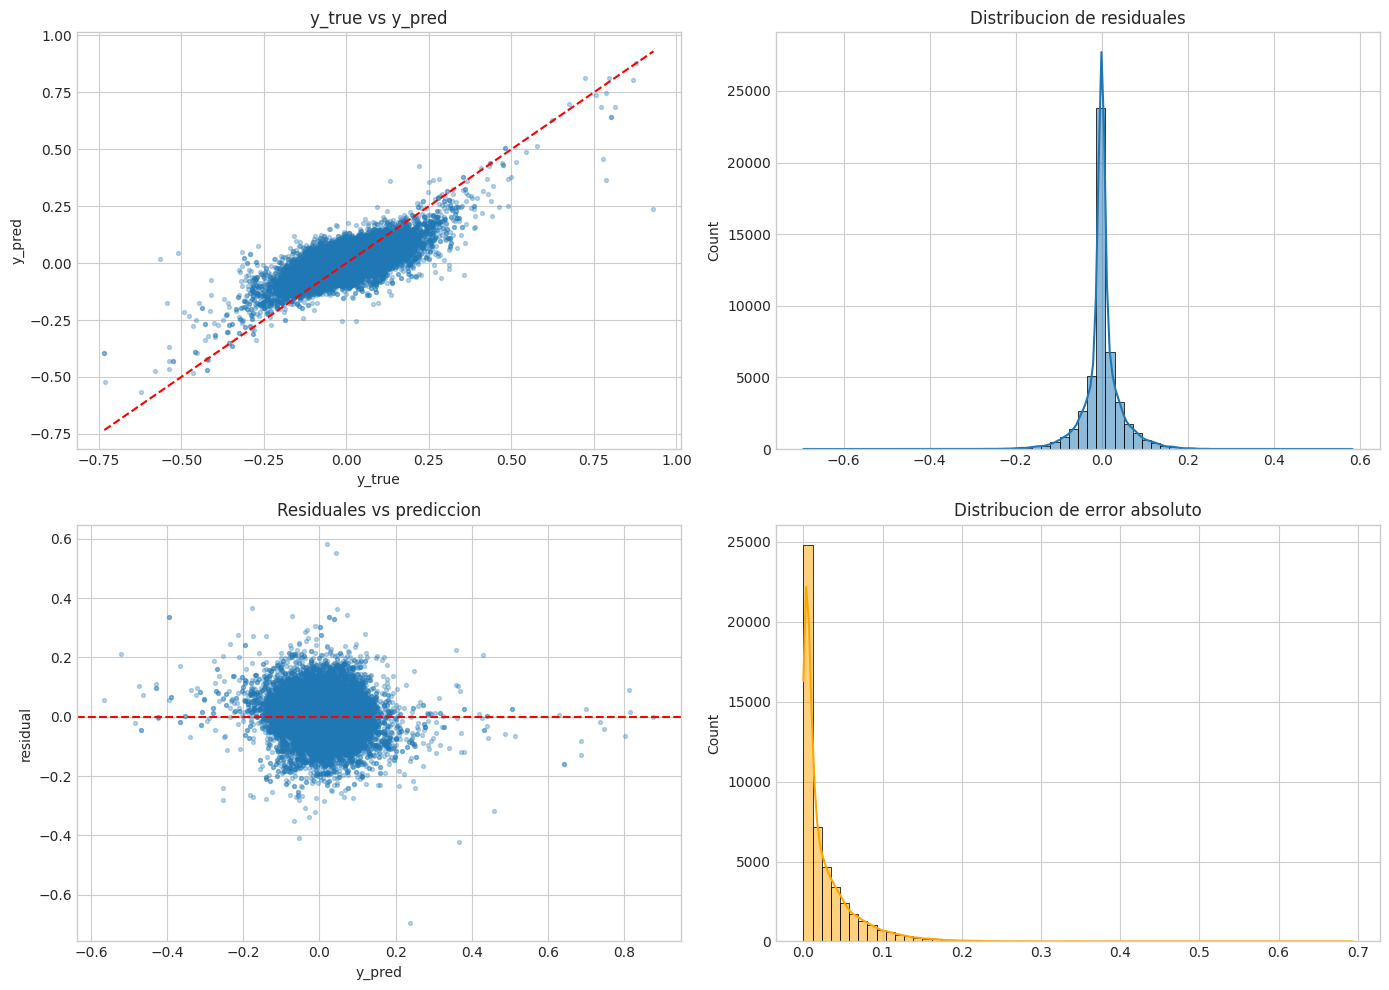

In [26]:
# Graficos base de diagnostico (con target convertido correctamente)
residuals = y_pred - y_true
abs_error = residuals.abs()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_true, y_pred, s=8, alpha=0.3)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
axes[0, 0].plot([mn, mx], [mn, mx], color='red', linestyle='--')
axes[0, 0].set_title('y_true vs y_pred')
axes[0, 0].set_xlabel('y_true')
axes[0, 0].set_ylabel('y_pred')

sns.histplot(residuals, bins=60, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribucion de residuales')

axes[1, 0].scatter(y_pred, residuals, s=8, alpha=0.3)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('y_pred')
axes[1, 0].set_ylabel('residual')

sns.histplot(abs_error, bins=60, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribucion de error absoluto')

plt.tight_layout()
plt.show()

In [27]:
# Analisis de fallos por segmentos (con y_true convertido correctamente)
df_diag = df_eval.loc[df_work.index].copy()
df_diag['y_true'] = y_true.values
df_diag['y_pred'] = y_pred.values
df_diag['residual'] = df_diag['y_pred'] - df_diag['y_true']
df_diag['abs_error'] = df_diag['residual'].abs()

if SPEED_COL in df_diag.columns:
    df_diag['speed_bin'] = pd.cut(
        df_diag[SPEED_COL],
        bins=[-0.1, 20, 40, 60, 90, np.inf],
        labels=['0-20', '20-40', '40-60', '60-90', '90+']
    )


def group_error_report(df: pd.DataFrame, group_col: str, min_n: int = 50) -> pd.DataFrame:
    if group_col not in df.columns:
        return pd.DataFrame()

    rep = (
        df.groupby(group_col, dropna=False)
        .agg(
            n=('abs_error', 'size'),
            mae=('abs_error', 'mean'),
            rmse=('residual', lambda s: float(np.sqrt(np.mean(np.square(s))))),
            bias=('residual', 'mean'),
            p95_abs=('abs_error', lambda s: float(np.percentile(s, 95))),
        )
        .reset_index()
    )

    rep = rep[rep['n'] >= min_n].sort_values(['mae', 'rmse'], ascending=False)
    return rep


segment_reports = {}
for col in SEGMENT_COL_CANDIDATES + (['speed_bin'] if 'speed_bin' in df_diag.columns else []):
    report = group_error_report(df_diag, col, min_n=MIN_GROUP_SIZE)
    if not report.empty:
        segment_reports[col] = report
        print(f'Top segmentos problematicos para: {col}')
        display(report.head(12))

if not segment_reports:
    print('No se pudieron construir reportes por segmentos con las columnas candidatas.')

Top segmentos problematicos para: fecha


,fecha,n,mae,rmse,bias,p95_abs
0,01/10/2025,1611,0.046090,0.061340,0.004166,0.124822
1,29/09/2025,46196,0.026406,0.044184,0.001700,0.098946
2,30/09/2025,1631,0.006291,0.012211,0.001699,0.015871


Top segmentos problematicos para: road_name


,road_name,n,mae,rmse,bias,p95_abs
20,Avenida de la Vega,242,0.048545,0.066365,-0.018674,0.137277
47,Calle de Murcia,273,0.045548,0.068918,-0.004070,0.156353
14,Avenida de Rafael Nadal,820,0.043048,0.060487,-0.002515,0.119694
39,Calle de Anabel Segura,424,0.041027,0.063497,0.004642,0.153619
41,Calle de Jaén,5026,0.036603,0.058300,-0.001061,0.121683
53,Paseo de Fuente Lucha,10048,0.032956,0.049524,0.001130,0.108974
16,Avenida de Valdelaparra,1322,0.032624,0.053023,0.019821,0.126159
58,NaN,4750,0.031875,0.049224,0.004175,0.107995
12,Avenida de Madrid,477,0.027703,0.045339,-0.005486,0.098561
26,Calle Fantasía,338,0.027334,0.043504,0.004536,0.101439


Top segmentos problematicos para: highway


,highway,n,mae,rmse,bias,p95_abs
10,NaN,1587,0.046593,0.061749,0.004187,0.125004
2,motorway_link,359,0.031770,0.050003,0.018398,0.108375
7,trunk,1690,0.031717,0.051451,0.018625,0.124705
4,residential,29903,0.028316,0.046710,0.000391,0.103493
3,primary,2864,0.024227,0.039260,0.000277,0.094047
6,tertiary,5954,0.020230,0.037034,0.002763,0.087829
5,secondary,6844,0.017964,0.031688,0.001768,0.072528


Top segmentos problematicos para: speed_bin


,speed_bin,n,mae,rmse,bias,p95_abs
3,60-90,887,0.045253,0.060448,0.004241,0.123396
4,90+,445,0.033534,0.047374,0.001228,0.098628
0,0-20,31109,0.027662,0.045825,0.001102,0.101808
1,20-40,14279,0.023483,0.040217,0.002989,0.092461
2,40-60,2718,0.019658,0.037524,0.002487,0.091796


In [7]:
# Casos con mayor error absoluto (inspeccion directa)
worst_cases = df_diag.sort_values('abs_error', ascending=False).head(TOP_K_WORST)
cols_for_review = [c for c in [TARGET_COL, 'y_pred', 'abs_error', SPEED_COL, 'phi_lidar', 'tri', 'ruggedness', 'road_name', 'fecha'] if c in worst_cases.columns]
display(worst_cases[cols_for_review])

,gy,y_pred,abs_error,speed_kmh,phi_lidar,tri,ruggedness,road_name,fecha
22749,53310.25,0.237037,53310.012963,2.52,-0.001550,0.314351,0.008087,Calle de Jaén,29/09/2025
49220,50357.04,0.877045,50356.162955,80.88,0.001291,0.301810,0.005582,NaN,01/10/2025
48454,49740.16,0.803220,49739.356780,71.03,0.000367,0.375283,0.008498,NaN,01/10/2025
48963,46673.29,0.687050,46672.602950,57.57,0.002175,0.317392,0.006220,NaN,01/10/2025
4851,45947.12,0.641724,45946.478276,32.91,-0.000544,1.743908,0.064800,Avenida de los Pirineos,29/09/2025
35625,45947.12,0.641724,45946.478276,32.91,-0.000544,1.743908,0.064800,Avenida de los Pirineos,29/09/2025
48730,45662.66,0.814542,45661.845458,43.78,0.000630,0.324495,0.006669,NaN,01/10/2025
8123,45136.88,0.747547,45136.132453,24.67,0.000313,0.156668,0.003607,Calle de Anabel Segura,29/09/2025
21227,45063.37,0.366107,45063.003893,1.32,-0.000657,0.361958,0.008412,Calle de Jaén,29/09/2025
21715,44468.37,0.458010,44467.911990,0.16,-0.001077,0.460043,0.013535,Calle de Jaén,29/09/2025


Top importancia MDI


,feature,importance_mdi
2,gz,0.353901
0,ax,0.258890
5,yaw,0.145784
1,gx,0.090164
3,roll,0.068409
4,pitch,0.052997
6,phi_lidar,0.011040
7,ruggedness,0.009594
8,z_std,0.004730
9,tri,0.004490


Permutation sobre dataset completo: 49,438 filas
Features para permutation: 10
Permutation finalizado en 11.6s con 3 repeticiones
Top permutation importance


,feature,importance_perm_mean,importance_perm_std
2,gz,0.014263,0.000116
0,ax,0.010624,0.000017
1,gx,0.001901,0.000041
4,pitch,0.001100,0.000025
3,roll,0.000684,0.000009
5,yaw,0.000600,0.000020
7,ruggedness,0.000170,0.000019
6,phi_lidar,0.000169,0.000005
8,z_std,0.000143,0.000002
9,tri,0.000029,0.000006


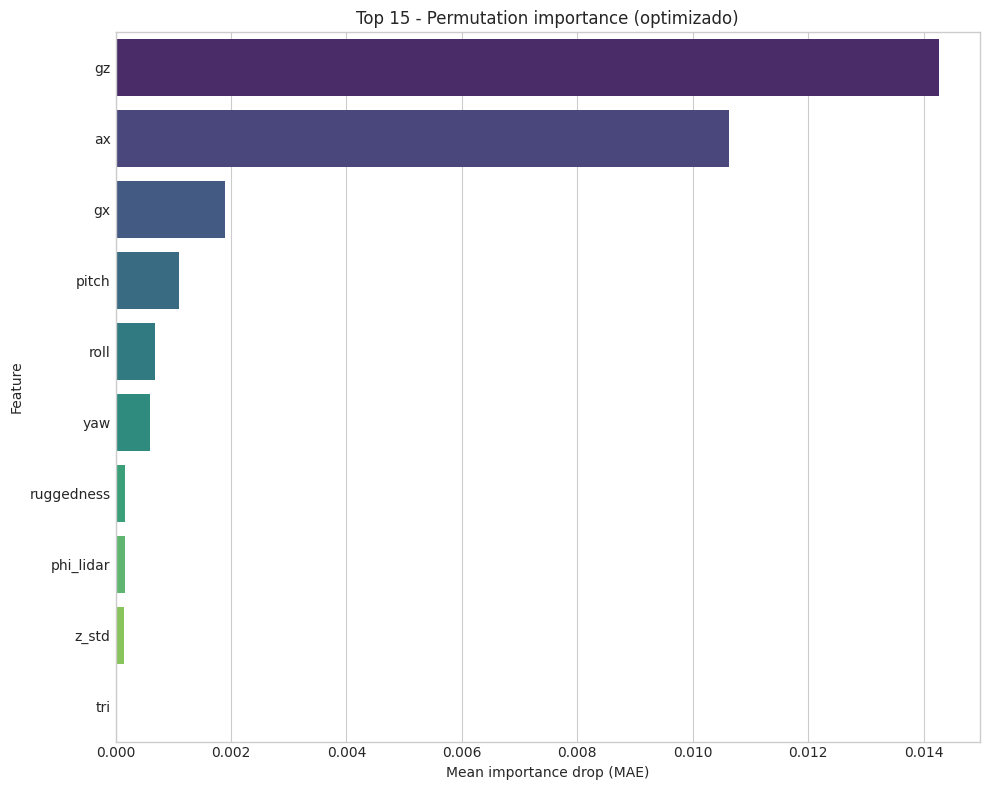

In [8]:
# Importancia global: MDI del modelo y permutation importance (version optimizada)
import time

mdi_df = pd.DataFrame()
if hasattr(model, 'feature_importances_'):
    mdi_df = pd.DataFrame({
        'feature': feature_cols,
        'importance_mdi': model.feature_importances_,
    }).sort_values('importance_mdi', ascending=False)
    print('Top importancia MDI')
    display(mdi_df.head(20))

# Parametros para acelerar permutation importance con datasets grandes
PERM_MAX_SAMPLES = 120_000
PERM_MAX_FEATURES = 20

perm_repeats = N_PERMUTATION_REPEATS if len(X_eval) <= 300_000 else max(3, min(5, N_PERMUTATION_REPEATS))
perm_n = min(PERM_MAX_SAMPLES, len(X_eval))

if perm_n < len(X_eval):
    sample_idx = X_eval.sample(n=perm_n, random_state=42).index
    X_perm = X_eval.loc[sample_idx].copy()
    y_perm = y_true.loc[sample_idx].copy()
    print(f'Permutation sobre muestra: {perm_n:,} / {len(X_eval):,} filas')
else:
    X_perm = X_eval.copy()
    y_perm = y_true.copy()
    print(f'Permutation sobre dataset completo: {len(X_eval):,} filas')

if not mdi_df.empty and len(feature_cols) > PERM_MAX_FEATURES:
    perm_features = mdi_df.head(PERM_MAX_FEATURES)['feature'].tolist()
    X_perm = X_perm[perm_features]
    print(f'Features para permutation: top {len(perm_features)} segun MDI')
else:
    perm_features = list(X_perm.columns)
    print(f'Features para permutation: {len(perm_features)}')

t0 = time.perf_counter()
perm = permutation_importance(
    model,
    X_perm,
    y_perm,
    n_repeats=perm_repeats,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
)
dt = time.perf_counter() - t0

perm_df = pd.DataFrame({
    'feature': perm_features,
    'importance_perm_mean': perm.importances_mean,
    'importance_perm_std': perm.importances_std,
}).sort_values('importance_perm_mean', ascending=False)

print(f'Permutation finalizado en {dt:.1f}s con {perm_repeats} repeticiones')
print('Top permutation importance')
display(perm_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(15), x='importance_perm_mean', y='feature', palette='viridis')
plt.title('Top 15 - Permutation importance (optimizado)')
plt.xlabel('Mean importance drop (MAE)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [9]:
# SHAP opcional (global y local)
if 'FAST_MODE' in globals() and FAST_MODE:
    print('SHAP omitido en FAST_MODE para cumplir presupuesto de tiempo.')
else:
    shap_available = True
    try:
        import shap
    except Exception as ex:
        shap_available = False
        print('SHAP no disponible. Instala con: pip install shap')
        print('Detalle:', ex)

    if shap_available:
        sample_n = min(N_SHAP_SAMPLES, len(X_eval))
        X_shap = X_eval.sample(n=sample_n, random_state=42) if len(X_eval) > sample_n else X_eval.copy()

        # Para modelos de arboles, TreeExplainer suele ser la opcion mas estable
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_shap)
        except Exception:
            explainer = shap.Explainer(model.predict, X_shap)
            shap_values = explainer(X_shap)

        print('Resumen SHAP global')
        shap.summary_plot(shap_values, X_shap, show=True)

        top_features = perm_df.head(3)['feature'].tolist() if 'perm_df' in globals() else feature_cols[:3]
        for feat in top_features:
            if feat in X_shap.columns:
                shap.dependence_plot(feat, shap_values, X_shap, show=True)

        # Explicacion local sobre casos de mayor error
        print('Explicacion local SHAP en casos con mayor error')
        worst_idx = df_diag.sort_values('abs_error', ascending=False).head(3).index
        X_local = X_eval.loc[worst_idx]

        try:
            local_vals = explainer.shap_values(X_local) if hasattr(explainer, 'shap_values') else explainer(X_local)
            shap.summary_plot(local_vals, X_local, show=True)
        except Exception as ex:
            print('No se pudo generar SHAP local:', ex)

SHAP omitido en FAST_MODE para cumplir presupuesto de tiempo.


## Plantilla de conclusiones accionables

Usa esta estructura al cerrar el analisis:

1. **Que tan bien funciona**: resume RMSE, MAE, R2, sesgo, p95 error.
2. **Donde falla**: lista top segmentos por MAE/RMSE y top casos de error.
3. **Por que falla**: cruza SHAP/permutation con segmentos para identificar causas probables.
4. **Que cambiar primero**: prioriza acciones en datos, features y modelo.
5. **Como validar la mejora**: define test A/B o comparacion antes/despues con mismas metricas.

In [10]:
# Validacion explicita del artefacto guardado por adaptive_hyperparam_search
artifact = joblib.load(Path(MODEL_PATH))
print('Tipo artefacto:', type(artifact).__name__)
if isinstance(artifact, dict):
    print('Claves:', sorted(artifact.keys()))
    model_from_artifact = artifact.get('model', None)
    print('Tipo artifact["model"]:', type(model_from_artifact).__name__ if model_from_artifact is not None else None)
    print('Tiene predict():', hasattr(model_from_artifact, 'predict') if model_from_artifact is not None else False)
    if 'feature_columns' in artifact:
        print('N feature_columns:', len(artifact['feature_columns']))
else:
    print('Tiene predict():', hasattr(artifact, 'predict'))
    print('Nota: artefacto no dict, se usa directo como estimador')

Tipo artefacto: dict
Claves: ['feature_columns', 'model', 'model_key', 'search_best', 'search_constraints', 'target_name']
Tipo artifact["model"]: GradientBoostingRegressor
Tiene predict(): True
N feature_columns: 10


In [11]:
# Inspeccion adicional del contenedor de modelos
artifact = joblib.load(Path(MODEL_PATH))
arts = artifact.get('artifacts', None) if isinstance(artifact, dict) else None
print('Tipo artifacts:', type(arts).__name__)

if isinstance(arts, dict):
    print('Claves artifacts:', list(arts.keys())[:20])
    for key, value in arts.items():
        print(f"artifact['artifacts'][{key!r}] tipo:", type(value).__name__, '| predict:', hasattr(value, 'predict'))
        if isinstance(value, dict):
            print('  subclaves:', list(value.keys())[:20])
            for k in ['model', 'estimator', 'pipeline', 'best_model', 'feature_columns']:
                if k in value:
                    v = value[k]
                    print(f'  value[{k!r}] tipo:', type(v).__name__, '| predict:', hasattr(v, 'predict'))
elif isinstance(arts, list):
    print('Cantidad artifacts:', len(arts))
    if len(arts) > 0:
        first = arts[0]
        print('Tipo primer item:', type(first).__name__)
        if isinstance(first, dict):
            print('Claves primer item:', sorted(first.keys())[:20])
else:
    print('Contenido no reconocido para artifacts')

Tipo artifacts: NoneType
Contenido no reconocido para artifacts


In [12]:
# Inspeccion de metadatos/score del artefacto para alinear R2
artifact = joblib.load(Path(MODEL_PATH))
arts = artifact.get('artifacts', {}) if isinstance(artifact, dict) else {}

for model_key, info in arts.items():
    print('\nMODEL_KEY:', model_key)
    if isinstance(info, dict):
        print('subclaves:', sorted(info.keys()))
        for k in ['target_name', 'run_id', 'feature_columns', 'metrics', 'cv', 'scores', 'best_score', 'r2', 'train_r2', 'val_r2', 'test_r2']:
            if k in info:
                v = info[k]
                if isinstance(v, (dict, list)):
                    print(f'- {k}: tipo {type(v).__name__} (len={len(v) if hasattr(v, "__len__") else "NA"})')
                else:
                    print(f'- {k}: {v}')

        model_obj = info.get('model', None)
        print('model tipo:', type(model_obj).__name__ if model_obj is not None else None)
        print('model has predict:', hasattr(model_obj, 'predict') if model_obj is not None else False)
        if model_obj is not None:
            attrs = [a for a in dir(model_obj) if 'target' in a.lower() or 'scale' in a.lower() or 'score' in a.lower()]
            print('attrs relacionados (sample):', attrs[:20])

In [13]:
# Inspeccion rapida de columnas target candidatas en df_eval
if 'df_eval' in globals():
    target_like = [c for c in df_eval.columns if any(k in c.lower() for k in ['omega', 'gyro', 'gy', 'rad', 'target'])]
    print('Columnas candidatas target (sample):', target_like[:80])
    print('Existe gy:', 'gy' in df_eval.columns)
    print('Existe omega_rad_s:', 'omega_rad_s' in df_eval.columns)
    if 'gy' in df_eval.columns:
        print('gy describe:')
        print(df_eval['gy'].describe(percentiles=[0.5, 0.9, 0.95]).to_string())


Columnas candidatas target (sample): ['gy']
Existe gy: True
Existe omega_rad_s: False
gy describe:
count    49438.000000
mean       -63.797347
std       3905.692854
min     -42017.850000
50%       -130.370000
90%       3919.992000
95%       6299.834500
max      53310.250000


In [14]:
# Prueba de alineacion de escala: gy (mdeg/s) -> omega_rad_s
from sklearn.metrics import r2_score

if 'X_eval' in globals() and 'model' in globals() and 'df_work' in globals() and 'gy' in df_work.columns:
    y_pred_probe = pd.Series(model.predict(X_eval), index=df_work.index)

    # Conversión típica si gy está en miligrados/segundo
    y_true_omega = df_work['gy'] * (np.pi / 180000.0)
    r2_omega = r2_score(y_true_omega, y_pred_probe)

    # Referencia actual en escala gy cruda
    r2_gy = r2_score(df_work['gy'], y_pred_probe)

    print('R2 con y_true=gy crudo         :', round(float(r2_gy), 6))
    print('R2 con y_true=gy->omega_rad_s  :', round(float(r2_omega), 6))
    print('rango y_pred:', float(y_pred_probe.min()), float(y_pred_probe.max()))
    print('rango y_true_omega:', float(y_true_omega.min()), float(y_true_omega.max()))

R2 con y_true=gy crudo         : -0.000249
R2 con y_true=gy->omega_rad_s  : 0.579974
rango y_pred: -0.5648103612301086 0.8770449557157628
rango y_true_omega: -0.7333498271090995 0.9304393875613072


In [15]:
# Revisar score interno del modelo (si existe)
if hasattr(model, 'oob_score_'):
    print('oob_score_ del modelo:', getattr(model, 'oob_score_'))
else:
    print('El modelo no expone oob_score_')

oob_score_ del modelo: 0.0007195514854285024


In [28]:
# Generacion de informe HTML autoexplicativo con graficas embebidas
import base64
import html
import io
from datetime import datetime

REPORT_DIR = REPO_ROOT / 'output' / 'results'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH = REPORT_DIR / f"model_diagnostic_{Path(MODEL_PATH).stem}.html"


def _df_to_html(df: pd.DataFrame, title: str, max_rows: int | None = None) -> str:
    if df is None or len(df) == 0:
        return f"<h3>{html.escape(title)}</h3><p>No hay datos disponibles.</p>"
    view = df.head(max_rows) if max_rows is not None else df
    return (
        f"<h3>{html.escape(title)}</h3>"
        + view.to_html(index=False, border=0, classes='table table-sm table-striped')
    )


def _fig_to_base64(fig) -> str:
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('ascii')


def _render_main_diagnostic_plot() -> str | None:
    if 'y_true' not in globals() or 'y_pred' not in globals():
        return None

    residuals_local = y_pred - y_true
    abs_error_local = residuals_local.abs()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].scatter(y_true, y_pred, s=8, alpha=0.3)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    axes[0, 0].plot([mn, mx], [mn, mx], color='red', linestyle='--')
    axes[0, 0].set_title('y_true vs y_pred')
    axes[0, 0].set_xlabel('y_true')
    axes[0, 0].set_ylabel('y_pred')

    sns.histplot(residuals_local, bins=60, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Distribucion de residuales')

    axes[1, 0].scatter(y_pred, residuals_local, s=8, alpha=0.3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_title('Residuales vs prediccion')
    axes[1, 0].set_xlabel('y_pred')
    axes[1, 0].set_ylabel('residual')

    sns.histplot(abs_error_local, bins=60, kde=True, ax=axes[1, 1], color='orange')
    axes[1, 1].set_title('Distribucion de error absoluto')

    plt.tight_layout()
    return _fig_to_base64(fig)


def _render_permutation_plot() -> str | None:
    if 'perm_df' not in globals() or perm_df is None or perm_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=perm_df.head(15), x='importance_perm_mean', y='feature', palette='viridis', ax=ax)
    ax.set_title('Top 15 - Permutation importance')
    ax.set_xlabel('Mean importance drop (MAE)')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    return _fig_to_base64(fig)


def _render_segment_plots() -> list[tuple[str, str]]:
    out = []
    if 'segment_reports' not in globals() or not isinstance(segment_reports, dict):
        return out

    for seg_name, seg_df in segment_reports.items():
        if seg_df is None or seg_df.empty:
            continue
        top_df = seg_df.head(10).copy()
        if 'mae' not in top_df.columns:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))
        labels = top_df[seg_name].astype(str)
        sns.barplot(x=top_df['mae'], y=labels, ax=ax, palette='mako')
        ax.set_title(f'Top 10 segmentos con mayor MAE - {seg_name}')
        ax.set_xlabel('MAE')
        ax.set_ylabel(seg_name)
        plt.tight_layout()
        out.append((seg_name, _fig_to_base64(fig)))

    return out


def _format_run_config(run_config) -> str:
    if run_config is None:
        return 'No disponible'
    if isinstance(run_config, (dict, list)):
        return json.dumps(run_config, ensure_ascii=False, indent=2)
    return str(run_config)


model_stem = Path(MODEL_PATH).stem
r2_current_val = float(r2_score(y_true, y_pred)) if 'y_true' in globals() and 'y_pred' in globals() else None

summary_cards = {
    'Modelo': model_stem,
    'Run ID': str(RUN_ID) if RUN_ID is not None else 'N/A',
    'Archivo modelo': str(MODEL_PATH),
    'Target evaluada': TARGET_COL,
    'Muestras evaluadas': f"{len(df_work):,}" if 'df_work' in globals() else 'N/A',
    'Features': f"{len(feature_cols)}" if 'feature_cols' in globals() else 'N/A',
    'R2 referencia entrenamiento': (
        f"{float(r2_reference):.6f}" if 'r2_reference' in globals() and r2_reference is not None else 'N/A'
    ),
    'R2 evaluacion actual': (
        f"{r2_current_val:.6f}" if r2_current_val is not None else 'N/A'
    ),
}

cards_html = ''.join(
    [
        f"<div class='card'><div class='k'>{html.escape(k)}</div><div class='v'>{html.escape(v)}</div></div>"
        for k, v in summary_cards.items()
    ]
)

main_plot_b64 = _render_main_diagnostic_plot()
perm_plot_b64 = _render_permutation_plot()
segment_plot_b64 = _render_segment_plots()

figures_blocks = []
if main_plot_b64 is not None:
    figures_blocks.append(
        "<h3>Grafica 1. Diagnostico general</h3>"
        "<p>Incluye ajuste y_true vs y_pred, distribucion de residuales, residuales vs prediccion y distribucion del error absoluto.</p>"
        f"<img class='plot' src='data:image/png;base64,{main_plot_b64}' alt='Diagnostico general' />"
    )

if perm_plot_b64 is not None:
    figures_blocks.append(
        "<h3>Grafica 2. Importancia por permutacion</h3>"
        "<p>Mide cuanto empeora el MAE al romper aleatoriamente cada feature. Mayor caida implica mayor importancia.</p>"
        f"<img class='plot' src='data:image/png;base64,{perm_plot_b64}' alt='Permutation importance' />"
    )

if segment_plot_b64:
    for seg_name, b64 in segment_plot_b64:
        figures_blocks.append(
            f"<h3>Grafica segmento: {html.escape(seg_name)}</h3>"
            "<p>Ranking de segmentos con mayor MAE para detectar contextos donde el modelo falla mas.</p>"
            f"<img class='plot' src='data:image/png;base64,{b64}' alt='Segmento {html.escape(seg_name)}' />"
        )

if not figures_blocks:
    figures_blocks.append('<p>No se pudieron generar graficas para este reporte.</p>')

sections = []
sections.append(_df_to_html(metrics_df, '1. Metricas globales', max_rows=30))

if 'segment_reports' in globals() and isinstance(segment_reports, dict):
    if segment_reports:
        for seg_name, seg_df in segment_reports.items():
            sections.append(_df_to_html(seg_df, f"2. Fallos por segmento: {seg_name}", max_rows=20))
    else:
        sections.append('<h3>2. Fallos por segmento</h3><p>No se generaron reportes por segmento.</p>')

if 'worst_cases' in globals():
    sections.append(_df_to_html(worst_cases, '3. Casos con mayor error absoluto', max_rows=TOP_K_WORST))

if 'mdi_df' in globals():
    sections.append(_df_to_html(mdi_df, '4. Importancia MDI', max_rows=20))

if 'perm_df' in globals():
    sections.append(_df_to_html(perm_df, '5. Permutation importance', max_rows=20))

metric_guide = """
<h3>Guia de metricas: significado e interpretacion</h3>
<table>
  <thead>
    <tr>
      <th>Metrica</th>
      <th>Que mide</th>
      <th>Si es alta</th>
      <th>Si es baja</th>
      <th>Como mejorarla</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>R2</strong></td>
      <td>Fraccion de variabilidad explicada por el modelo.</td>
      <td>Cercano a 1 indica buen ajuste global.</td>
      <td>Cercano a 0 o negativo indica poco poder predictivo.</td>
      <td>Agregar features relevantes, mejorar calidad de target, tuning, revisar drift y leakage.</td>
    </tr>
    <tr>
      <td><strong>RMSE</strong></td>
      <td>Raiz del error cuadratico medio (penaliza mucho errores grandes).</td>
      <td>Muchos outliers o grandes fallos locales.</td>
      <td>Errores grandes controlados.</td>
      <td>Tratar outliers, usar modelos robustos, segmentar por regimenes, mejorar cobertura de casos extremos.</td>
    </tr>
    <tr>
      <td><strong>MAE</strong></td>
      <td>Error absoluto promedio.</td>
      <td>Error medio alto en operaciones normales.</td>
      <td>Error promedio bajo y estable.</td>
      <td>Mejorar features base, limpiar ruido de sensores, recalibrar y reentrenar con mas datos representativos.</td>
    </tr>
    <tr>
      <td><strong>MedAE</strong></td>
      <td>Error absoluto mediano (robusto a outliers).</td>
      <td>Incluso el caso tipico falla bastante.</td>
      <td>Caso tipico bien modelado.</td>
      <td>Corregir sesgos sistematicos, revisar transformaciones de escala/unidades, mejor feature engineering.</td>
    </tr>
    <tr>
      <td><strong>MAPE</strong></td>
      <td>Error porcentual medio.</td>
      <td>Errores relativos altos (ojo con targets cercanos a 0).</td>
      <td>Error relativo bajo.</td>
      <td>Usar epsilon adecuado, evaluar tambien SMAPE/MAE, modelar por rangos de magnitud del target.</td>
    </tr>
    <tr>
      <td><strong>Bias mean error</strong></td>
      <td>Sesgo promedio firmado (sobre/subestimacion).</td>
      <td>Positivo: sobreestima; negativo: subestima.</td>
      <td>Cercano a 0 indica poco sesgo sistematico.</td>
      <td>Calibracion post-modelo, balancear dataset por rango objetivo, revisar shift entre train y eval.</td>
    </tr>
    <tr>
      <td><strong>P90/P95 abs error</strong></td>
      <td>Cola de errores absolutos (cuantiles altos).</td>
      <td>Riesgo operativo alto en peores casos.</td>
      <td>Peores casos bajo control.</td>
      <td>Entrenar con enfoque en cola (ponderaciones), reglas de fallback, deteccion de OOD.</td>
    </tr>
    <tr>
      <td><strong>Max abs error</strong></td>
      <td>Peor error observado.</td>
      <td>Existe al menos un caso extremo problematico.</td>
      <td>No hay fallos extremos severos.</td>
      <td>Auditar casos top-K, corregir datos anomalos, validar sensores y preprocesamiento.</td>
    </tr>
  </tbody>
</table>
<p><strong>Nota:</strong> en este reporte, <code>r2</code> corresponde al valor de referencia de entrenamiento (CV) del artefacto y <code>r2_eval_current</code> al calculado sobre el conjunto evaluado actualmente.</p>
"""

html_doc = f"""
<!doctype html>
<html lang=\"es\">
<head>
  <meta charset=\"utf-8\" />
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\" />
  <title>Informe Diagnostico de Regresion</title>
  <style>
    :root {{
      --bg: #f6f7fb;
      --paper: #ffffff;
      --ink: #142033;
      --muted: #516075;
      --line: #d9e0ea;
      --accent: #1f6feb;
    }}
    * {{ box-sizing: border-box; }}
    body {{ margin: 0; font-family: \"Segoe UI\", Tahoma, sans-serif; background: var(--bg); color: var(--ink); }}
    .wrap {{ max-width: 1240px; margin: 0 auto; padding: 24px; }}
    .hero {{ background: linear-gradient(135deg, #eaf2ff 0%, #f6faff 45%, #ffffff 100%); border: 1px solid var(--line); border-radius: 16px; padding: 20px; }}
    h1 {{ margin: 0 0 8px; font-size: 28px; }}
    h2 {{ margin: 24px 0 10px; font-size: 20px; }}
    h3 {{ margin: 20px 0 8px; font-size: 17px; }}
    p, li {{ color: var(--muted); line-height: 1.5; }}
    .cards {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 12px; margin-top: 14px; }}
    .card {{ background: var(--paper); border: 1px solid var(--line); border-radius: 12px; padding: 12px; }}
    .card .k {{ font-size: 12px; color: var(--muted); text-transform: uppercase; letter-spacing: .04em; }}
    .card .v {{ margin-top: 6px; font-size: 17px; font-weight: 600; color: var(--ink); word-break: break-word; }}
    .panel {{ margin-top: 16px; background: var(--paper); border: 1px solid var(--line); border-radius: 12px; padding: 14px; }}
    code, pre {{ background: #f1f5fb; border: 1px solid var(--line); border-radius: 8px; }}
    pre {{ padding: 10px; overflow: auto; white-space: pre-wrap; }}
    table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
    th, td {{ border: 1px solid var(--line); padding: 6px 8px; text-align: left; }}
    th {{ background: #f3f7fd; }}
    .plot {{ width: 100%; border: 1px solid var(--line); border-radius: 10px; background: white; margin: 8px 0 14px; }}
    .footer {{ margin-top: 24px; padding-top: 14px; border-top: 1px dashed var(--line); font-size: 12px; color: var(--muted); }}
  </style>
</head>
<body>
  <div class=\"wrap\">
    <section class=\"hero\">
      <h1>{html.escape(MODEL_TITLE if 'MODEL_TITLE' in globals() else f'Informe de diagnostico - {model_stem}')}</h1>
      <p>Documento autoexplicativo generado desde notebook. Resume desempeno global, patrones de error, casos criticos e importancia de variables.</p>
      <div class=\"cards\">{cards_html}</div>
    </section>

    <section class=\"panel\">
      <h2>Contexto de entrenamiento</h2>
      <p><strong>Comando original usado para entrenar el modelo:</strong></p>
      <pre>{html.escape(TRAIN_COMMAND if TRAIN_COMMAND else 'No definido')}</pre>
      <p><strong>Run config utilizado:</strong></p>
      <pre>{html.escape(_format_run_config(RUN_CONFIG))}</pre>
    </section>

    <section class=\"panel\">
      <h2>Interpretacion de metricas y acciones de mejora</h2>
      {metric_guide}
    </section>

    <section class=\"panel\">
      <h2>Graficas del diagnostico</h2>
      {''.join(figures_blocks)}
    </section>

    <section class=\"panel\">
      <h2>Tablas de resultados detallados</h2>
      {''.join(sections)}
    </section>

    <div class=\"footer\">
      Generado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | Notebook: model_diagnostic_regression.ipynb
    </div>
  </div>
</body>
</html>
"""

REPORT_PATH.write_text(html_doc, encoding='utf-8')
print('Reporte HTML generado en:', REPORT_PATH)
print('Tamano (bytes):', REPORT_PATH.stat().st_size)

Reporte HTML generado en: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/results/model_diagnostic_adaptive_doback_all_gbr_gbr_best.html
Tamano (bytes): 562716


In [17]:
# Anexo explicativo: permutation, MDI e interpretacion de graficas en el HTML
EXPLAIN_MARKER = '<!-- EXPLAIN_PERMUTATION_MDI_GRAPHICS -->'

explain_html = """
<section class=\"panel\">
  <!-- EXPLAIN_PERMUTATION_MDI_GRAPHICS -->
  <h2>Como interpretar Permutation, MDI y las graficas</h2>

  <h3>1) Permutation Importance (permutaciones)</h3>
  <p>
    Se evalua el impacto real de cada variable desordenando sus valores y midiendo cuanto empeora la metrica.
    En este diagnostico se usa MAE, por lo que una mayor caida del score equivale a un mayor aumento de error.
  </p>
  <ul>
    <li><strong>importance_perm_mean alto:</strong> la variable es critica para el desempeno.</li>
    <li><strong>importance_perm_mean cerca de cero:</strong> la variable aporta poco en presencia del resto.</li>
    <li><strong>importance_perm_mean negativo:</strong> ruido/inestabilidad o redundancia alta.</li>
    <li><strong>importance_perm_std alto:</strong> ranking poco estable entre repeticiones; interpretar con cautela.</li>
  </ul>
  <p>
    Ventaja: refleja impacto en generalizacion del modelo final.<br/>
    Limitacion: con variables muy correlacionadas puede subestimar su importancia individual.
  </p>

  <h3>2) MDI (Mean Decrease in Impurity)</h3>
  <p>
    Es la importancia interna de modelos de arboles: resume cuanto reduce la impureza (error) cada variable
    durante los splits del entrenamiento.
  </p>
  <ul>
    <li><strong>MDI alto:</strong> variable frecuentemente util para dividir nodos.</li>
    <li><strong>MDI bajo:</strong> menor contribucion en la estructura de arboles.</li>
  </ul>
  <p>
    Ventaja: muy rapido de calcular.<br/>
    Limitacion: puede sesgarse por cardinalidad y por colinealidad.
    Si MDI y Permutation difieren, prioriza Permutation para decisiones operativas.
  </p>

  <h3>3) Que representan las graficas del informe</h3>
  <ul>
    <li><strong>y_true vs y_pred:</strong> cercania a la diagonal implica buen ajuste.</li>
    <li><strong>Distribucion de residuales:</strong> centrada en 0 indica bajo sesgo global; colas largas indican casos extremos.</li>
    <li><strong>Residuales vs prediccion:</strong> patrones o embudos sugieren heterocedasticidad o falta de variables.</li>
    <li><strong>Distribucion de error absoluto:</strong> permite ver riesgo en cola (errores grandes poco frecuentes).</li>
    <li><strong>Barras de Permutation:</strong> ranking de impacto real de features sobre error.</li>
    <li><strong>Barras por segmento:</strong> muestran donde falla mas el modelo (contexto operativo).</li>
  </ul>

  <h3>4) Como actuar con esta informacion</h3>
  <ul>
    <li>Prioriza mejoras en las 3-5 features top por Permutation.</li>
    <li>Audita segmentos con mayor MAE y p95 para reducir riesgo operativo.</li>
    <li>Si hay gran brecha entre entrenamiento y evaluacion, revisa drift y muestreo.</li>
    <li>Si persisten colas de error, aplica estrategias robustas: winsorizacion, reponderacion de casos extremos o modelos por segmento.</li>
  </ul>
</section>
"""

if 'REPORT_PATH' not in globals():
    REPORT_PATH = REPO_ROOT / 'output' / 'results' / f"model_diagnostic_{Path(MODEL_PATH).stem}.html"

if not REPORT_PATH.exists():
    raise FileNotFoundError(f'No existe el reporte HTML: {REPORT_PATH}')

content = REPORT_PATH.read_text(encoding='utf-8')

if EXPLAIN_MARKER in content:
    print('La seccion explicativa ya existe en el HTML. No se realizaron cambios.')
else:
    if '<div class=\"footer\">' in content:
        content = content.replace('<div class=\"footer\">', explain_html + '\n<div class=\"footer\">')
    elif '</body>' in content:
        content = content.replace('</body>', explain_html + '\n</body>')
    else:
        content = content + '\n' + explain_html

    REPORT_PATH.write_text(content, encoding='utf-8')
    print('Seccion explicativa insertada en:', REPORT_PATH)
    print('Tamano actualizado (bytes):', REPORT_PATH.stat().st_size)

Seccion explicativa insertada en: /home/acastilla/Lidar-algority/LiDAR-Stability-algorithm/output/results/model_diagnostic_adaptive_doback_all_gbr_gbr_best.html
Tamano actualizado (bytes): 504406
